# Statistical test of the excited neutrino hypothesis using the monojet CMS data

- This notebook builds the likelihood function using the HEPData of the CMS monojet search, and performs a statistical test of the excited neutrino hypothesis.

- HEPData: https://www.hepdata.net/record/ins1894408  

- CMS note on simplified likelihoods: https://cds.cern.ch/record/2242860  



# Import the yields - both the background prediction and the observed data

- The yields are read from `monov_yields.yaml` file, which has the following structure:

```yaml
dependent_variables:
- header:
    name: Background yield
  values:
  - value: 9812.890625
  - value: 6159.333038
  ...

- header:
    name: Data yield
  values:
  - value: 9929
  - value: 6057
  ...

independent_variables:
- header:
    name: Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin1
  ...
```

In [1]:
# Read the yaml file.
import yaml
with open("data/monoj_yields.yaml", "r") as f:
    monov_yields = yaml.safe_load(f)

# Read the bin names, background yields, and data yields,
# excluding the 2016 bins.
monov_bkg = []
monov_data = []
bin_names = []
for index in range(len(monov_yields['independent_variables'][0]['values'])):
    bin_name = monov_yields['independent_variables'][0]['values'][index]['value']
    if '2016' not in bin_name:
        bin_names.append(bin_name)
        monov_bkg.append(monov_yields['dependent_variables'][0]['values'][index]['value'])
        monov_data.append(monov_yields['dependent_variables'][1]['values'][index]['value'])

for bin_name, bkg, data in zip(bin_names, monov_bkg, monov_data):
    print(f"{bin_name}: bkg = {bkg}, data = {data}")

monojet_2017_bin0: bkg = 169737.7734, data = 176171
monojet_2017_bin1: bkg = 93266.63818, data = 96067
monojet_2017_bin2: bkg = 54175.54321, data = 54789
monojet_2017_bin3: bkg = 32232.16919, data = 32767
monojet_2017_bin4: bkg = 19798.24585, data = 20209
monojet_2017_bin5: bkg = 12816.66046, data = 12910
monojet_2017_bin6: bkg = 10626.91895, data = 10653
monojet_2017_bin7: bkg = 6407.873535, data = 6487
monojet_2017_bin8: bkg = 3903.657227, data = 3955
monojet_2017_bin9: bkg = 2519.861908, data = 2587
monojet_2017_bin10: bkg = 1929.788399, data = 1957
monojet_2017_bin11: bkg = 1181.808949, data = 1151
monojet_2017_bin12: bkg = 713.7919903, data = 721
monojet_2017_bin13: bkg = 456.2266827, data = 455
monojet_2017_bin14: bkg = 294.6278095, data = 298
monojet_2017_bin15: bkg = 231.1669064, data = 244
monojet_2017_bin16: bkg = 146.4085865, data = 146
monojet_2017_bin17: bkg = 87.26129293, data = 89
monojet_2017_bin18: bkg = 69.26482379, data = 65
monojet_2017_bin19: bkg = 32.26833493, dat

# Import the covariance matrix

- The covariance matrix is read from `monov_cov.yaml` file, which had the following structure:

```yaml
dependent_variables:
- header:
    name: Covariance
  values:
  - value: 77980.32004
  - value: 27279.25967
  ...

independent_variables:
- header:
    name: First Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin0
  ...

- header:
    name: Second Bin
  values:
  - value: monovtau21_2016_bin0
  - value: monovtau21_2016_bin1
  ...
```

In [2]:
# Read the mono-V covariance matrix from the file monov_cov.yaml.
import yaml
import numpy as np
with open("data/monoj_cov.yaml", "r") as f:
    monov_cov = yaml.safe_load(f)

In [3]:
# Check that the order of bins in the covariance matrix matches the order of bins in the yields file.
bin_names_2 = []
for var in monov_cov['independent_variables'][0]['values']:
    name = var['value']
    if name not in bin_names_2 and '2016' not in name:
        bin_names_2.append(name)

assert bin_names_2 == bin_names

In [4]:
# Create the covariance matrix as a 2D numpy array, where the order of rows and columns corresponds to the order of bin names in the list created above.
cov_ndarray = np.zeros((len(bin_names), len(bin_names)))
for i, var1 in enumerate(bin_names):
    for j, var2 in enumerate(bin_names):
        # Find the covariance element for var1 and var2 in monov_cov and store it in cov_ndarray[i, j].
        for row_index in range(len(monov_cov['independent_variables'][0]['values'])):
            tmp_var1 = monov_cov['independent_variables'][0]['values'][row_index]['value']
            tmp_var2 = monov_cov['independent_variables'][1]['values'][row_index]['value']
            if (tmp_var1 == var1 and tmp_var2 == var2):
                cov_ndarray[i, j] = monov_cov['dependent_variables'][0]['values'][row_index]['value']
                break


The cell below just checks that the 2016 bins are discarded correctly.

In [5]:
# Check that the covariance matrix cov_ndarray was read correctly.

def find_index(i1, i2):
    """
    Find the index in monov_cov corresponding to the covariance element between bins with indices i1 and i2 in bin_names.

    The offset of 22 corresponds to the 2016 bins, which are not included in bin_names.
    """
    i1 += 22
    i2 += 22
    return (len(bin_names) + 22) * i1 + i2


from math import isclose
for i1 in range(len(bin_names)):
    for i2 in range(len(bin_names)):
        index = find_index(i1, i2)
        cov_value = cov_ndarray[i1, i2]
        yaml_value = monov_cov['dependent_variables'][0]['values'][index]['value']
        condition = isclose(cov_value, yaml_value, rel_tol=1e-9)
        condition = condition and (monov_cov['independent_variables'][0]['values'][index]['value'] == bin_names[i1])
        condition = condition and (monov_cov['independent_variables'][1]['values'][index]['value'] == bin_names[i2])
        if not condition:
            print(f"Mismatch at i1={i1}, i2={i2}: cov_value={cov_value}, yaml_value={yaml_value}, bin1={monov_cov['independent_variables'][0]['values'][index]['value']}, bin2={monov_cov['independent_variables'][1]['values'][index]['value']}")
            break
else:
    print("All values match.")


All values match.


# Likelihood function

The likelihood function is given by:

$$
\mathcal L_\mathrm{S} = \prod_{i=1}^{n} \frac{(\mu s_i + b_i + \theta_i)^{n_i} e^{-(\mu s_i + b_i + \theta_i)}}{n_i!} e^{-\frac{1}{2} \sum_{i,j} \theta_i V^{-1}_{ij} \theta_j}
$$

The negative log-likelihood is then:

$$
-2 \ln \mathcal L_\mathrm{S} = -2 \sum_{i=1}^{n} \left( n_i \ln(\mu s_i + b_i + \theta_i) - (\mu s_i + b_i + \theta_i) \right) + \sum_{i,j} \theta_i V^{-1}_{ij} \theta_j,
$$

where the term $-2 \ln n_i!$ is dropped as it does not depend on the parameters of interest.

In [67]:
import numpy as np
V = cov_ndarray
n = np.array(monov_data)
b = np.array(monov_bkg)
s = np.array([1.006524e+00, 9.487730e-01, 9.858989e-01, 1.056026e+00, 1.072526e+00, 1.167403e+00, 1.485036e+00, 1.592289e+00, 1.612914e+00, 1.678916e+00,  2.165677e+00,  2.330681e+00,  2.211054e+00,  2.145052e+00,  2.025424e+00,  2.392558e+00,  2.149177e+00,  1.827419e+00,  1.905796e+00,  1.563413e+00,  1.518037e+00,  2.037799e+00,
              1.151231e+00,  1.056284e+00,  1.145297e+00,  1.240244e+00,  1.258046e+00,  1.418269e+00,  1.620031e+00,  2.160042e+00,  2.225318e+00,  2.302462e+00,  2.990827e+00,  3.251931e+00,  3.038300e+00,  3.032366e+00,  2.866209e+00,  3.412154e+00,  2.907748e+00,  2.516092e+00,  2.676315e+00,  2.290593e+00,  2.189712e+00,  2.854341e+00])
init_theta = np.zeros(len(b))
mu = 1

def log_likelihood_factory(s, n, b, V):

    # theta[0] corresponds to the POI mu, and theta[1:] correspond to the nuisance parameters.
    def log_likelihood(params):
        mu    = params[0]
        theta = np.array(params[1:])
        t = mu * s + b + theta
        nll = -2 * np.sum(n * np.log(t) - t)
        nll += theta @ np.linalg.inv(V) @ theta
        return nll
        
    return log_likelihood

In [7]:
# Create dictionary with C, m, t0 and pickle it to the file cms_monov_inputs.pkl.
import pickle
inputs = {
    'V': V,
    'n': n,
    'b': b,
    's': s
}
with open("data/cms_monoj_inputs.pkl", "wb") as f:
    pickle.dump(inputs, f)

Plot the data and the background prediction, and the signal prediction for the excited neutrino hypothesis.

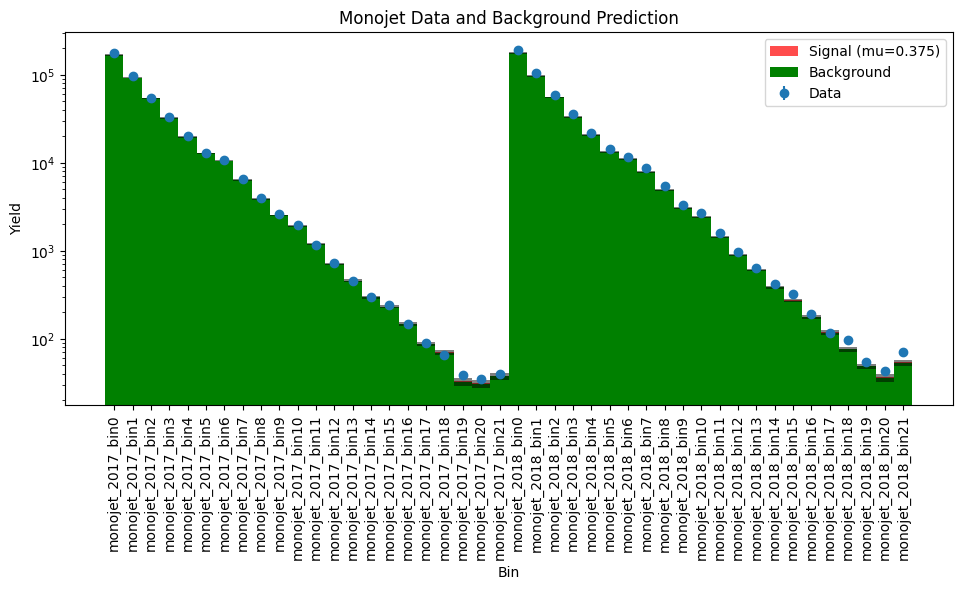

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.errorbar(bin_names, n, yerr=np.sqrt(np.diag(V)), fmt='o', label='Data')
# Plot the signal prediction for the excited neutrino hypothesis, which is given by b + s * mu.
plt.hist(bin_names, weights=b + s * mu, bins=np.arange(len(bin_names)+1)-0.5, alpha=0.7, label=f'Signal (mu={mu})', color='red')
plt.hist(bin_names, weights=b, bins=np.arange(len(bin_names)+1)-0.5, alpha=1, label='Background', color='green')
# Plot the uncertainty on the background prediction as shaded rectangles with centers at the background prediction and heights corresponding to the square root of the diagonal elements of the covariance matrix.
for i in range(len(bin_names)):
    plt.gca().add_patch(plt.Rectangle((i-0.5, b[i] - np.sqrt(V[i, i])), 1, 2*np.sqrt(V[i, i]), color='black', alpha=0.5, linewidth=0))
plt.xticks(rotation=90)
plt.xlabel('Bin')
plt.ylabel('Yield')
plt.title('Monojet Data and Background Prediction')
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.show()

Plot the difference between the data and the background prediction, divided by the background uncertainty.

Also, plot the difference divided by the square root of the background yield, which is the Poisson uncertainty of the background yield.

The two graphs above can be shown in the same plot, split into two subplots.

/tmp/ipykernel_9288/616489396.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_9288/616489396.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


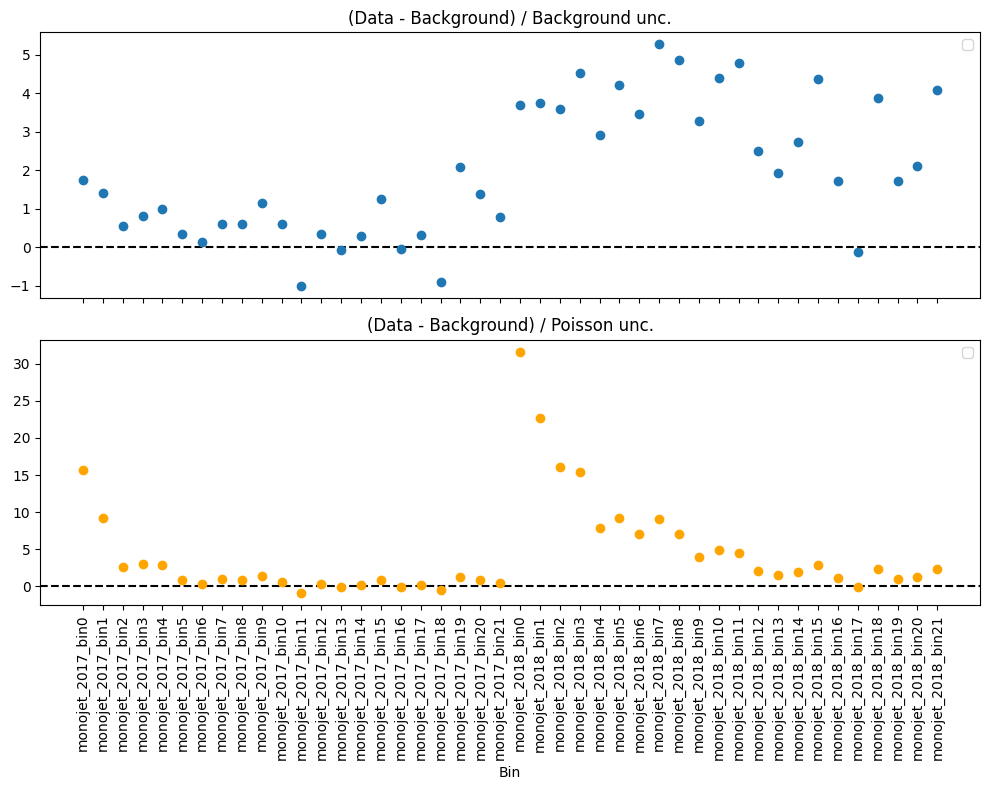

In [9]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Plot the difference between the data and the background prediction, divided by the background uncertainty.
ax1.errorbar(bin_names, (n - b) / np.sqrt(np.diag(V)), fmt='o')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('(Data - Background) / Background unc.')
ax1.legend()
# Plot the difference between the data and the background prediction, divided by the square root of the background yield, which is the Poisson uncertainty of the background yield.
ax2.errorbar(bin_names, (n - b) / np.sqrt(b), fmt='o', color='orange')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('Bin')
ax2.set_title('(Data - Background) / Poisson unc.')
ax2.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Find the minimum of the likelihood function with respect to the model parameters.

In [10]:
from iminuit import Minuit

def find_minimum(nll, init_params, fix_mu = False):
    minuit = Minuit(nll, init_params)
    if fix_mu:
        minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()

    # Return the value at the minimum and the uncertainty on that value.
    return minuit.values[0], minuit.errors[0]


We have functions to compute the estimator $\hat{\mu}$ and its uncertainty.
As the next step, we will define the test statistic, which is:
$$q_\mu = \begin{cases} 0 & \text{if } \hat{\mu} > \mu \\
        -2 \ln \lambda(\mu) & \text{if } \hat{\mu} \leq \mu
\end{cases}$$
where
$$
-2 \ln \lambda(\mu) = -2 \ln \frac{L(\mu, \hat{\hat{\theta}}(\mu))}{L(\hat{\mu}, \hat{\theta})}
$$

In [11]:
# The test statistic.
def test_statistic(nll, mu, init_theta):

    # Minimizer.
    minuit = Minuit(nll, [mu] + list(init_theta))

    # Global minimum.
    minuit.migrad()
    minuit.hesse()
    mu_hat = minuit.values[0]

    # Return zero if mu_hat > mu.
    if mu_hat > mu:
        return 0
    
    # Denominator - evaluate the nll function at the global minimum.
    global_min = minuit.fval

    # Nominator.
    minuit.values[0] = mu
    minuit.fixed[0] = True
    minuit.migrad()
    minuit.hesse()
    constraint_min = minuit.fval

    return constraint_min - global_min

# Pseudo-experiments

As the next step, we will generate pseudo-experiments to determine the distribution of the test statistic.

Each pseudo-experiment will consist of generating the pseudo-data $n_i$ according to the model with fixed $\mu$ and then computing the test statistic for that pseudo-dataset.

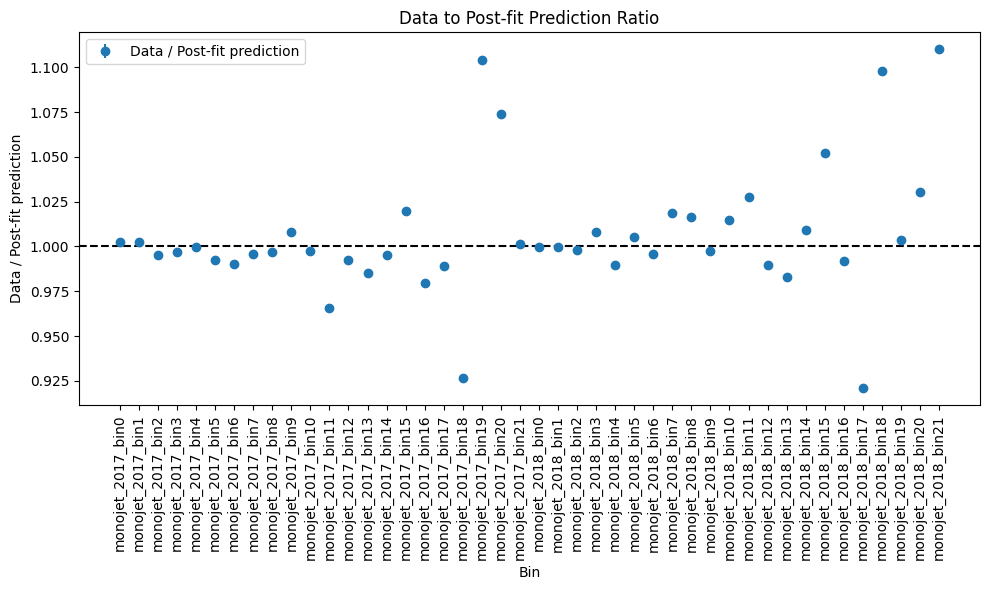

In [68]:
# Perform the fit and plot the ratio of the data to the post-fit prediction, which is given by mu_hat * s + b + theta_hat, where mu_hat and theta_hat are the values of the parameters at the minimum of the nll function.
nll = log_likelihood_factory(s, n, b, V)
minuit = Minuit(nll, [mu] + list(init_theta))
minuit.fixed[0] = True
minuit.migrad()
minuit.hesse()

# plot the ratio
post_fit_prediction = minuit.values[0] * s + b + np.array(minuit.values[1:])
plt.figure(figsize=(10, 6))
plt.errorbar(bin_names, n / post_fit_prediction, yerr=0, fmt='o', label='Data / Post-fit prediction')
plt.axhline(1, color='black', linestyle='--')
plt.xticks(rotation=90)
plt.xlabel('Bin')
plt.ylabel('Data / Post-fit prediction')
plt.title('Data to Post-fit Prediction Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# Generate the pseudo-experiments from the postfit nu = mu*s + b prediction.
# Here, nu is a vector of expected yields in each bin.
def generate_pseudo_experiments(mu, s, nu, b, V, n_toys = 1000):
    nu = mu * s + b
    pseudo_experiments = np.random.poisson(nu, size=(n_toys, len(nu)))
    print(pseudo_experiments[0])

    # evaluate the theta_hat values for the Asimov data to get a reasonable starting point for the minimization of the pseudo-experiments.
    nll_asimov = log_likelihood_factory(s, nu, b, V)
    minuit = Minuit(nll_asimov, [mu] + list(init_theta))
    minuit.migrad()
    minuit.hesse()

    ts_toys = []
    for i in range(len(pseudo_experiments)):
        pseudo_n = pseudo_experiments[i]
        nll = log_likelihood_factory(s, pseudo_n, b, V)
        ts = test_statistic(nll, mu, init_theta)
        ts_toys.append(ts)

    return np.array(ts_toys)

# generate_pseudo_experiments(mu, s, mu * s + b, b, V, n_toys = 1000)

ts_toys_postfit = generate_pseudo_experiments(mu, s, post_fit_prediction, b, V, n_toys = 2000)


[169587  93038  54180  32202  19694  12994  10588   6348   3877   2595
   1856   1137    736    475    307    222    139     98     57     45
     31     44 177959  97470  55834  32698  20550  13353  10909   7932
   4972   2977   2356   1476    917    578    399    296    201    120
     72     54     37     55]


In [71]:
ts_toys = ts_toys_postfit

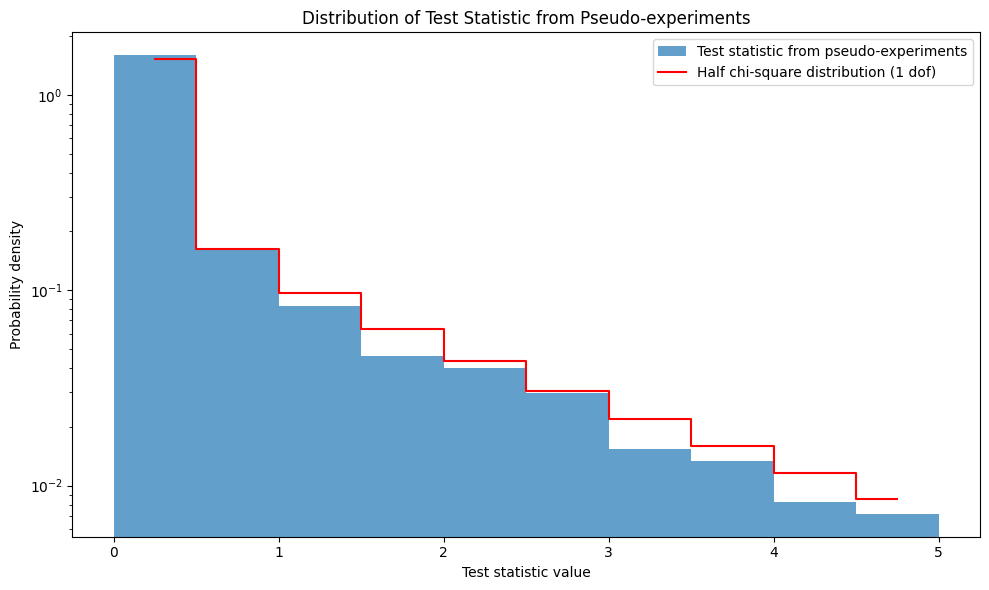

Chi-squared value: 13.253416245297561
Chi-squared test p-value: 0.20984617099383604


In [72]:
# plot the histogram of the test statistic values from the pseudo-experiments.
# Also plot the half-chi-square distribution with 1 degree of freedom as a histogram.
# Half chi-square distribution is the sum of two parts: a delta function at zero with weight 0.5, and a chi-square distribution with 1 degree of freedom with weight 0.5.
import matplotlib.pyplot as plt
from scipy.stats import chi2
n_bins = 10
upper_bound = 5
plt.figure(figsize=(10, 6))
# split the interval [0, upper_bound] into n_bins bins, and plot the histogram of the test statistic values from the pseudo-experiments in these bins, normalized to form a probability density.
# add the events with test statistic value above the upper_bound to the last bin.
bin_edges = np.linspace(0, upper_bound, n_bins + 1)
plt.hist(ts_toys, bins=bin_edges, density=True, alpha=0.7, label='Test statistic from pseudo-experiments')

x = np.linspace(0, upper_bound, 100)
# Prepare the histogram of the half chi-square distribution.
# For this, evaluate the chi-square cdf at the bin edges, and take the difference to get the probability for each bin. Then, multiply by 0.5 to get the half chi-square distribution.
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
half_chi2_hist = 0.5 * (chi2.cdf(bin_edges[1:], df=1) - chi2.cdf(bin_edges[:-1], df=1))
half_chi2_hist /= (bin_edges[1] - bin_edges[0])  # Normalize by the bin width to get the probability density.
half_chi2_hist[0] += 0.5 / (bin_edges[1] - bin_edges[0])  # Add the delta function at zero.
plt.step(bin_centers, half_chi2_hist, where='mid', label='Half chi-square distribution (1 dof)', color='red')
plt.xlabel('Test statistic value')
plt.ylabel('Probability density')
plt.yscale('log')
plt.title('Distribution of Test Statistic from Pseudo-experiments')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate the chi-square goodness of fit test for the histogram of the test statistic values from the pseudo-experiments, comparing it to the half chi-square distribution with 1 degree of freedom.
from scipy.stats import chisquare
# For this, evaluate the expected number of pseudo-experiments in each bin according to the half chi-square distribution, and compare it to the observed number of pseudo-experiments in each bin.
observed_counts, _ = np.histogram(ts_toys, bins=bin_edges)
expected_counts = half_chi2_hist * len(ts_toys) * (bin_edges[1] - bin_edges[0])  # Expected counts in each bin according to the half chi-square distribution.
chi_squared_value = np.sum((observed_counts - expected_counts) ** 2 / expected_counts)
print(f'Chi-squared value: {chi_squared_value}')
# Calculate the p-value for the chi-square test with the appropriate number of degrees of freedom, which is the number of bins minus 1.
p_value = chi2.sf(chi_squared_value, df=n_bins)
print(f'Chi-squared test p-value: {p_value}')

# Non-centrality parameter

Under the assumption that $\mu = \mu'$, the test statistic $q_\mu$ is distributed as a non-central chi-square distribution with one degree of freedom and non-centrality parameter $\Lambda$.
The $\Lambda$ parameter can be estimated using the Asimov dataset, $\nu_i^\text{A} = \mu' s_i + b_i$, and the following formulae:

$$
C^{-1}_{ij} = - \frac{\partial^2 \ln \mathcal L_\mathrm{S}^\text{A}}{\partial \theta_i \partial \theta_j} = \frac{1}{2} \frac{\partial^2 (-2 \ln \mathcal L_\mathrm{S}^\text{A})}{\partial \theta_i \partial \theta_j},
$$
where
$$
C^{-1}_{ij} = \text{cov}(\theta_i, \theta_j)
$$
and $\theta_0 = \mu$.
I think the second derivatives are to be evaluated at the minimum of $-2 \ln \mathcal L_\mathrm{S}^\text{A}$, i.e. at $\hat{\theta} = (\mu', 0, 0, \ldots, 0)$.

$$
\Lambda = \frac{(\mu - \mu')^2}{\sigma^2},
$$
where $\sigma^2 = \text{cov}(\mu, \mu) = C_{00}$.

See Eq. (28) in https://arxiv.org/abs/1007.1727

In [12]:
# Note that mu' = 0 in our case, so we set n = b to get the Asimov dataset.
nll_a = log_likelihood_factory(s, b, b, V)

from iminuit import Minuit
minuit = Minuit(nll_a, [0] + list(init_theta))
minuit.migrad()
minuit.hesse()
sigma = np.sqrt(minuit.covariance[0, 0])

print(sigma)

# More practical way, using the existing find_minimum function.
mu_hat, sigma_2 = find_minimum(nll_a, [0] + list(init_theta))
print(sigma_2)



1.1930101387059864
1.1930101387059864


# CLs value calculation

We know that:

- The test statistic distribution under the signal hypothesis $\mu$ is the chi-squared distribution with 1 degree of freedom.

- The test statistic distribution under the background-only hypothesis $\mu' = 0$ is the non-central chi-squared distribution with 1 degree of freedom and non-centrality parameter $\Lambda = (\mu - \mu')^2 / \sigma^2 = \mu^2 / \sigma^2$

The CLs value can be calculated as:
$$
CLs = \frac{p_{\text{signal}}}{p_{\text{background}}}
$$
where $p_{\text{signal}}$ ($p_{\text{background}}$) is the p-value under the signal (background-only) hypothesis.

In [ ]:
from scipy.stats import chi2, ncx2
from scipy.stats import norm

def p_value_bkg(s, n, b, V, mu):

    nll = log_likelihood_factory(s, n, b, V)
    observed_ts = test_statistic(nll, mu, init_theta)

    # p_bkg calculation
    nll_a = log_likelihood_factory(s, b, b, V)
    _, sigma = find_minimum(nll_a, [0] + list(init_theta))
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = mu ** 2 / sigma ** 2)

    return p_bkg

def cls(s, n, b, V, mu, n_sigma = None):
    """Calculate the CLs value.

    mu: signal hypothesis
    n_sigma: number of standard deviations for expected limits; if None, calculate the observed CLs; if a number, calculate the expected CLs for that number of standard deviations.
    """
    nll = log_likelihood_factory(s, n, b, V)
    observed_ts = test_statistic(nll, mu, init_theta)

    # calculate the sigma for the non-centrality parameter
    nll_a = log_likelihood_factory(s, b, b, V)
    _, sigma = find_minimum(nll_a, [0] + list(init_theta))
    observed_ts_a = test_statistic(nll_a, mu, init_theta)

    # non-centrality parameter for the background-only hypothesis
    nc = mu ** 2 / sigma ** 2

    # shift the observed test statistic if n_sigma is not None
    if n_sigma is not None:
        # For expected limits, we evaluate the median of the background-only test statistic distribution, and the quantiles corresponding to the n_sigma standard deviations, as the observed test statistic value.
        probability = norm.cdf(n_sigma)
        observed_ts = ncx2.ppf(probability, df = 1, nc = nc)
        # Just a check.
        if n_sigma == 0:
            print(observed_ts, observed_ts_a, (observed_ts - observed_ts_a) / observed_ts_a)

    # p-values
    p_bkg = ncx2.sf(observed_ts, df = 1, nc = nc)
    p_sig = chi2.sf(observed_ts, df = 1)

    return p_sig / p_bkg

In [18]:
print(cls(s, n, b, V, mu, n_sigma = 0))

0.5525158750182824 0.09807601571083069 4.6335473154550995
0.9145830545904227


# Hypothesis test inversion

- Scan over the parameter $\theta$ values and compute the p-value for each of them.

- Plot the p-value as a function of $\theta$.

- Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

In [ ]:
# Do a hypothesis test inversion to find the 95% confidence level upper limit on the parameter $\theta$.
# Scan over the parameter $\theta$ values and compute the p-value for each of them, using the theoretical distribution of the test statistic under the null hypothesis (chi-squared distribution with 1 degree of freedom).
# Plot the p-value as a function of $\theta$.
# Linearly interpolate the p-value curve to find the value of $\theta$ for which the p-value is equal to 0.05. This will give us the 95% confidence level upper limit on $\theta$.

import numpy as np
from scipy.stats import chi2

mu_values = np.linspace(0, 10, 10)
p_values = []
cls_values = []
p_values_bkg = []
nll = log_likelihood_factory(s, n, b, V)
for mu_val in mu_values:
    observed_ts = test_statistic(nll, mu_val, init_theta)
    p_values.append(chi2.sf(observed_ts, df=1))
    cls_values.append(cls(s, n, b, V, mu_val))
    p_values_bkg.append(p_value_bkg(s, n, b, V, mu_val))


In [ ]:
# Plot the p-value as a function of mu:
plt.plot(mu_values, p_values, marker='o', label='p')
plt.plot(mu_values, p_values_bkg, marker='s', label='p_bkg')
plt.plot(mu_values, cls_values, marker='^', label='CLs')
plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
plt.xlabel(r'$\mu$')
plt.ylabel('P-value')
plt.title('P-value as a function of mu')
plt.ylim(0, 1)
plt.legend()
plt.show()

# Expected limits

- The expected limit is calculated by using the asimov dataset, which is the dataset that corresponds to the background-only prediction.

- The $\pm 1\sigma$ and $\pm 2\sigma$ expected limits can be calculated by using the asimov dataset and evaluating the quantile of the test statistic distribution under the background-only hypothesis that corresponds to the desired n_sigma value.

In [ ]:
limits = {n_sigma: [] for n_sigma in [-2, -1, 0, 1, 2]} # will have n_sigma as keys
asimov = b
for mu_val in mu_values:
    for n_sigma in [-2, -1, 0, 1, 2]:
        cls_value = cls(s, n, b, V, mu_val, n_sigma = n_sigma)
        limits[n_sigma].append(cls_value)

In [ ]:
# Draw the expected limit as a black dashed line.
# Draw the +- 1 sigma and +/- 2 sigma expected limits as green and yellow bands, respectively.
# Draw the observed CLs values as a black solid line.
plt.plot(mu_values, limits[0], color='black', linestyle='dashed', label='Expected limit')
plt.fill_between(mu_values, limits[-1], limits[1], color='green', alpha=0.5, label='Expected limit ± 1σ')
plt.fill_between(mu_values, limits[-2], limits[2], color='yellow', alpha=0.5, label='Expected limit ± 2σ')
plt.plot(mu_values, cls_values, color='black', label='Observed CLs')
plt.axhline(0.05, color='red', linestyle='dashed', label='p-value = 0.05')
plt.xlabel(r'$\mu$')
plt.ylabel('CLs')
plt.title('CLs as a function of mu')
plt.legend()
plt.show()

# Upper limit on the signal strength

- The upper limit on the signal strength $\theta$ is the value of $\theta$ for which the p-value is equal to 0.05, as calculated in the hypothesis test inversion step.

- The present algorithm:

1. Go through the list of CLs values, starting from the highest index.
2. Check if the CLs value is less than 0.05.
3. If yes, then check if the next CLs value (at index lower by 1) is greater than 0.05.
4. If yes, then perform linear interpolation between these two points to find the value of $\theta$ for which the CLs value is equal to 0.05. This will give us the upper limit on $\theta$ at 95% confidence level.

In [ ]:
def find_upper_limit(mu_values, cls_values):
    upper_limit = None
    i = len(mu_values) - 1
    while i > 0 and cls_values[i] < 0.05:
        if cls_values[i - 1] > 0.05:
            # Perform the linear interpolation.
            theta1 = mu_values[i - 1]
            theta2 = mu_values[i]
            cls1 = cls_values[i - 1]
            cls2 = cls_values[i]
            upper_limit = theta1 + (0.05 - cls1) * (theta2 - theta1) / (cls2 - cls1)
        i -= 1
    return upper_limit

obs_limit = find_upper_limit(mu_values, cls_values)
exp_limit = find_upper_limit(mu_values, limits[0])
print(f"Observed upper limit on theta at 95% CL: {obs_limit}")
print(f"Expected upper limit on theta at 95% CL: {exp_limit}")
for n_sigma in [-2, -1, 0, 1, 2]:
    limit = find_upper_limit(mu_values, limits[n_sigma])
    print(f"Expected upper limit on theta at 95% CL for n_sigma={n_sigma}: {limit}")